In [1]:
# ===============================
# 0. УСТАНОВКА
# ===============================
!pip install -q ultralytics ensemble-boxes

# ===============================
# 1. ИМПОРТЫ
# ===============================
import os
import yaml
import random
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
import torch
import cv2
from ensemble_boxes import weighted_boxes_fusion
import json
from collections import defaultdict
import matplotlib.pyplot as plt

# ===============================
# 2. SEED
# ===============================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ===============================
# 3. ПУТИ
# ===============================
base_path = '/kaggle/input/competitions/dl-lab-2-stuff-detection'
yolo_base = f'{base_path}/yolo_dataset/yolo_dataset'

train_images_path = f'{yolo_base}/train/images'
train_labels_path = f'{yolo_base}/train/labels'
test_path = f'{base_path}/test_images/test_images'
sample_sub_path = f'{base_path}/sample_sub.csv'

# ===============================
# 4. ДЕТАЛЬНЫЙ АНАЛИЗ ДАТАСЕТА
# ===============================
print("="*60)
print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ДАТАСЕТА")
print("="*60)

def analyze_dataset_detailed():
    """Подробный анализ датасета с проверкой формата"""
    class_counts = {0: 0, 1: 0}  # 0: customer, 1: staff
    images_with_boxes = 0
    boxes_per_image = []
    class_in_images = {0: 0, 1: 0}  # В скольких изображениях есть класс
    staff_sizes = []  # для анализа размеров staff
    
    # Для проверки формата
    all_coords_valid = True
    format_errors = []
    
    train_images = os.listdir(train_images_path)
    
    for img in tqdm(train_images, desc="Анализ"):
        label_path = os.path.join(train_labels_path, img.replace('.jpg', '.txt'))
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                if lines:
                    images_with_boxes += 1
                    boxes_per_image.append(len(lines))
                    
                    # Анализируем каждый бокс
                    classes_in_this_img = set()
                    
                    for line in lines:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            coords = [float(x) for x in parts[1:5]]
                            
                            # Сохраняем размеры staff для анализа
                            if class_id == 1:
                                w = float(parts[3])
                                h = float(parts[4])
                                staff_sizes.append(np.sqrt(w * h))
                            
                            # Проверяем валидность координат (должны быть в [0,1])
                            if not all(0 <= x <= 1 for x in coords):
                                all_coords_valid = False
                                format_errors.append(f"{img}: coords={coords}")
                            
                            if class_id in [0, 1]:
                                class_counts[class_id] += 1
                                classes_in_this_img.add(class_id)
                            else:
                                format_errors.append(f"{img}: invalid class={class_id}")
                    
                    # Считаем изображения с каждым классом
                    for c in classes_in_this_img:
                        class_in_images[c] += 1
    
    print(f"\n📊 СТАТИСТИКА:")
    print(f"Всего изображений: {len(train_images)}")
    print(f"Изображений с боксами: {images_with_boxes} ({images_with_boxes/len(train_images)*100:.2f}%)")
    print(f"\nОБЪЕКТЫ ПО КЛАССАМ:")
    print(f"  customer (0): {class_counts[0]} объектов в {class_in_images[0]} изображениях")
    print(f"  staff (1):    {class_counts[1]} объектов в {class_in_images[1]} изображениях")
    
    if class_counts[0] > 0:
        print(f"\nСоотношение staff/customer: {class_counts[1]/class_counts[0]:.3f}")
    
    print(f"\nСреднее боксов на изображение с объектами: {np.mean(boxes_per_image):.2f}")
    print(f"Медиана боксов: {np.median(boxes_per_image):.2f}")
    print(f"Максимум боксов: {max(boxes_per_image)}")
    
    # Анализ размеров staff
    if staff_sizes:
        staff_sizes = np.array(staff_sizes)
        print(f"\n📊 АНАЛИЗ РАЗМЕРОВ STAFF:")
        print(f"  Минимальный: {staff_sizes.min():.4f}")
        print(f"  Максимальный: {staff_sizes.max():.4f}")
        print(f"  Средний: {staff_sizes.mean():.4f}")
        print(f"  Медиана: {np.median(staff_sizes):.4f}")
        print(f"  1-й перцентиль: {np.percentile(staff_sizes, 1):.4f}")
        print(f"  99-й перцентиль: {np.percentile(staff_sizes, 99):.4f}")
    
    print(f"\n✅ Координаты валидны: {all_coords_valid}")
    if format_errors:
        print(f"❌ Найдено ошибок формата: {len(format_errors)}")
        print(f"Пример: {format_errors[0]}")
    
    return class_counts, class_in_images, boxes_per_image, staff_sizes

class_counts, class_in_images, boxes_per_image, staff_sizes = analyze_dataset_detailed()

# ===============================
# 5. БАЛАНСИРОВКА КЛАССОВ
# ===============================
total_objects = class_counts[0] + class_counts[1]
class_weights = {
    0: total_objects / (2 * class_counts[0]) if class_counts[0] > 0 else 1.0,
    1: total_objects / (2 * class_counts[1]) if class_counts[1] > 0 else 1.0
}

print(f"\n📊 ВЕСА КЛАССОВ ДЛЯ LOSS:")
print(f"  customer: {class_weights[0]:.3f}")
print(f"  staff:    {class_weights[1]:.3f}")

# ===============================
# 6. РАЗДЕЛЕНИЕ ДАННЫХ СТРАТИФИЦИРОВАННО
# ===============================
def stratify_by_class(train_images):
    """Разделение с учетом наличия каждого класса"""
    images_by_type = {
        'both': [],  # есть оба класса
        'customer_only': [],  # только customer
        'staff_only': [],  # только staff
        'none': []  # без объектов
    }
    
    for img in train_images:
        label_path = os.path.join(train_labels_path, img.replace('.jpg', '.txt'))
        has_customer = False
        has_staff = False
        
        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path, 'r') as f:
                for line in f:
                    class_id = int(line.strip().split()[0])
                    if class_id == 0:
                        has_customer = True
                    elif class_id == 1:
                        has_staff = True
        
        if has_customer and has_staff:
            images_by_type['both'].append(img)
        elif has_customer:
            images_by_type['customer_only'].append(img)
        elif has_staff:
            images_by_type['staff_only'].append(img)
        else:
            images_by_type['none'].append(img)
    
    return images_by_type

train_images = os.listdir(train_images_path)
images_by_type = stratify_by_class(train_images)

print("\n📊 РАСПРЕДЕЛЕНИЕ ИЗОБРАЖЕНИЙ:")
for k, v in images_by_type.items():
    print(f"  {k}: {len(v)} ({len(v)/len(train_images)*100:.2f}%)")

# Разделяем каждую группу отдельно
train_imgs = []
val_imgs = []

for group_name, group_images in images_by_type.items():
    if len(group_images) > 0:
        test_size = 0.15 if group_name in ['both', 'staff_only'] else 0.2
        if len(group_images) < 10:
            train_g, val_g = train_test_split(
                group_images, 
                test_size=min(0.2, 1/len(group_images)),
                random_state=42
            )
        else:
            train_g, val_g = train_test_split(
                group_images, 
                test_size=test_size,
                random_state=42
            )
        train_imgs.extend(train_g)
        val_imgs.extend(val_g)

print(f"\n✅ ИТОГОВОЕ РАЗДЕЛЕНИЕ:")
print(f"  Train: {len(train_imgs)} изображений")
print(f"  Val: {len(val_imgs)} изображений")

# ===============================
# 7. СОЗДАНИЕ ДАТАСЕТА
# ===============================
!mkdir -p /kaggle/working/dataset/train/images
!mkdir -p /kaggle/working/dataset/train/labels
!mkdir -p /kaggle/working/dataset/val/images
!mkdir -p /kaggle/working/dataset/val/labels

def copy_files(img_list, split):
    for img in tqdm(img_list, desc=f"Копирование {split}"):
        shutil.copy(f'{train_images_path}/{img}',
                    f'/kaggle/working/dataset/{split}/images/{img}')

        label = img.replace('.jpg','.txt')
        src_label = f'{train_labels_path}/{label}'

        if os.path.exists(src_label):
            shutil.copy(src_label,
                        f'/kaggle/working/dataset/{split}/labels/{label}')

copy_files(train_imgs,'train')
copy_files(val_imgs,'val')

# ===============================
# 8. DATA.YAML
# ===============================
data_yaml = {
    'path': '/kaggle/working/dataset',
    'train': 'train/images',
    'val': 'val/images',
    'nc': 2,
    'names': ['customer', 'staff']
}

with open('/kaggle/working/dataset/data.yaml','w') as f:
    yaml.dump(data_yaml, f)

# ===============================
# 9. УЛУЧШЕННОЕ ОБУЧЕНИЕ
# ===============================
print("\n" + "="*60)
print("🚀 УЛУЧШЕННОЕ ОБУЧЕНИЕ")
print("="*60)

model = YOLO('yolov8m.pt')

# УСИЛЕННАЯ АУГМЕНТАЦИЯ для staff
results = model.train(
    data='/kaggle/working/dataset/data.yaml',
    epochs=80,  # Увеличим для лучшей сходимости
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.0005,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    
    # 🚀 УЛУЧШЕННАЯ АУГМЕНТАЦИЯ
    hsv_h=0.02,        # увеличен разброс оттенка
    hsv_s=0.8,         # увеличен разброс насыщенности
    hsv_v=0.5,         # увеличен разброс яркости
    degrees=15.0,      # больший угол поворота
    translate=0.15,    # больший сдвиг
    scale=0.6,         # больший масштаб
    shear=3.0,         # больший сдвиг
    perspective=0.0007,
    flipud=0.5,
    fliplr=0.5,
    mosaic=1.0,
    
    # 🚀 НОВЫЕ АУГМЕНТАЦИИ
    mixup=0.3,         # увеличен mixup
    copy_paste=0.4,    # увеличен copy_paste
    erasing=0.2,       # случайное стирание частей
    crop_fraction=0.5, # случайное обрезание
    
    close_mosaic=10,
    dropout=0.15,      # увеличен dropout
    
    project='/kaggle/working/yolo_balanced',
    name='staff_detector_v8m_improved',
    exist_ok=True,
    patience=15,
    seed=42,
)

# ===============================
# 10. ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ
# ===============================
model_path = '/kaggle/working/yolo_balanced/staff_detector_v8m_improved/weights/best.pt'
if os.path.exists(model_path):
    model = YOLO(model_path)
    print("✅ Загружена лучшая модель")
else:
    print("❌ Модель не найдена")
    model = YOLO('/kaggle/working/yolo_balanced/staff_detector_v8m_improved/weights/last.pt')

# ===============================
# 11. ОПТИМИЗАЦИЯ ПОРОГА (на валидации)
# ===============================
print("\n" + "="*60)
print("🔍 ОПТИМИЗАЦИЯ ПОРОГА")
print("="*60)

# Используем валидационные изображения для поиска лучшего порога
val_images = os.listdir('/kaggle/working/dataset/val/images')[:100]  # первые 100 для быстроты

thresholds = [0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05]
best_threshold = 0.02
best_f1 = 0

for thresh in thresholds:
    # Здесь можно посчитать метрики на валидации
    # Для простоты используем количество детекций
    total_detections = 0
    for img_name in tqdm(val_images, desc=f"Тест порога {thresh}", leave=False):
        img_path = f'/kaggle/working/dataset/val/images/{img_name}'
        results = model.predict(img_path, conf=thresh, classes=[1], verbose=False)[0]
        if results.boxes is not None:
            total_detections += len(results.boxes)
    
    print(f"Порог {thresh}: {total_detections} детекций")
    if total_detections > best_f1:
        best_f1 = total_detections
        best_threshold = thresh

print(f"\n✅ Лучший порог: {best_threshold}")

# ===============================
# 12. ФИНАЛЬНОЕ ПРЕДСКАЗАНИЕ
# ===============================
print("\n" + "="*60)
print("🚀 ФИНАЛЬНОЕ ПРЕДСКАЗАНИЕ")
print("="*60)

sample_sub = pd.read_csv(sample_sub_path)

def predict_staff(img_path, conf_threshold):
    img = cv2.imread(img_path)
    if img is None:
        return []
    
    h, w, _ = img.shape
    results = model.predict(img, conf=conf_threshold, classes=[1], verbose=False)[0]
    
    if results.boxes is None or len(results.boxes) == 0:
        return []
    
    boxes_xyxy = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()
    
    final_boxes = []
    min_size_thresh = 0.01  # минимальный размер из анализа
    
    for box, score in zip(boxes_xyxy, scores):
        x1, y1, x2, y2 = box
        width = (x2 - x1) / w
        height = (y2 - y1) / h
        
        # Фильтрация по размеру
        if width * height < min_size_thresh * min_size_thresh:
            continue
        
        x_center = ((x1 + x2) / 2) / w
        y_center = ((y1 + y2) / 2) / h
        
        final_boxes.append([
            float(x_center),
            float(y_center),
            float(width),
            float(height),
            float(score)
        ])
    
    return final_boxes

pred_boxes_json = []
images_with_staff = 0
total_staff = 0

for idx, img_name in enumerate(tqdm(sample_sub['image_name'], desc="Предсказание")):
    img_path = os.path.join(test_path, img_name)
    
    if not os.path.exists(img_path):
        pred_boxes_json.append("[]")
        continue
    
    boxes = predict_staff(img_path, best_threshold)
    
    if len(boxes) > 0:
        images_with_staff += 1
        total_staff += len(boxes)
        pred_boxes_json.append(json.dumps(boxes, separators=(',', ':')))
    else:
        pred_boxes_json.append("[]")

# ===============================
# 13. СОЗДАНИЕ SUBMISSION (ИСПРАВЛЕНО!)
# ===============================
submission = pd.DataFrame({
    'id': sample_sub['id'],
    'image_name': sample_sub['image_name'],
    'boxes': pred_boxes_json
})

# ===============================
# 14. СТАТИСТИКА
# ===============================
print("\n" + "="*60)
print("📊 СТАТИСТИКА")
print("="*60)
print(f"Всего изображений: {len(submission)}")
print(f"С изображений со staff: {images_with_staff}")
print(f"Без staff: {len(submission) - images_with_staff}")
print(f"Всего staff детекций: {total_staff}")
print(f"Среднее staff на изображение: {total_staff/len(submission):.2f}")
print(f"Ожидаемое (из train): 0.94")

# ===============================
# 15. СОХРАНЕНИЕ
# ===============================
output_path = '/kaggle/working/submission_improved.csv'
submission.to_csv(output_path, index=False)
print(f"\n✅ SUBMISSION СОХРАНЕН: {output_path}")

from IPython.display import FileLink
display(FileLink(output_path))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ДАТАСЕТА


Анализ: 100%|██████████| 3908/3908 [00:38<00:00, 101.82it/s]



📊 СТАТИСТИКА:
Всего изображений: 3908
Изображений с боксами: 3908 (100.00%)

ОБЪЕКТЫ ПО КЛАССАМ:
  customer (0): 17066 объектов в 3481 изображениях
  staff (1):    4060 объектов в 3089 изображениях

Соотношение staff/customer: 0.238

Среднее боксов на изображение с объектами: 5.41
Медиана боксов: 4.00
Максимум боксов: 24

📊 АНАЛИЗ РАЗМЕРОВ STAFF:
  Минимальный: 0.0087
  Максимальный: 0.4716
  Средний: 0.1547
  Медиана: 0.1270
  1-й перцентиль: 0.0239
  99-й перцентиль: 0.3725

✅ Координаты валидны: True

📊 ВЕСА КЛАССОВ ДЛЯ LOSS:
  customer: 0.619
  staff:    2.602

📊 РАСПРЕДЕЛЕНИЕ ИЗОБРАЖЕНИЙ:
  both: 2662 (68.12%)
  customer_only: 819 (20.96%)
  staff_only: 427 (10.93%)
  none: 0 (0.00%)

✅ ИТОГОВОЕ РАЗДЕЛЕНИЕ:
  Train: 3279 изображений
  Val: 629 изображений


Копирование val: 100%|██████████| 629/629 [00:11<00:00, 54.03it/s]



🚀 УЛУЧШЕННОЕ ОБУЧЕНИЕ
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.4, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=staff_dete

...

Порог 0.04: 99 детекций


Порог 0.05: 97 детекций

✅ Лучший порог: 0.01

🚀 ФИНАЛЬНОЕ ПРЕДСКАЗАНИЕ


Предсказание: 100%|██████████| 4454/4454 [03:16<00:00, 22.71it/s]



📊 СТАТИСТИКА
Всего изображений: 4454
С изображений со staff: 2234
Без staff: 2220
Всего staff детекций: 4975
Среднее staff на изображение: 1.12
Ожидаемое (из train): 0.94

✅ SUBMISSION СОХРАНЕН: /kaggle/working/submission_improved.csv


/kaggle/working/submission_improved.csv

📊 АНАЛИЗ РЕЗУЛЬТАТОВ МОДЕЛИ

🔍 АНАЛИЗ НА ВАЛИДАЦИИ...


Анализ валидации: 100%|██████████| 200/200 [00:04<00:00, 41.01it/s]


NameError: name 'glob' is not defined

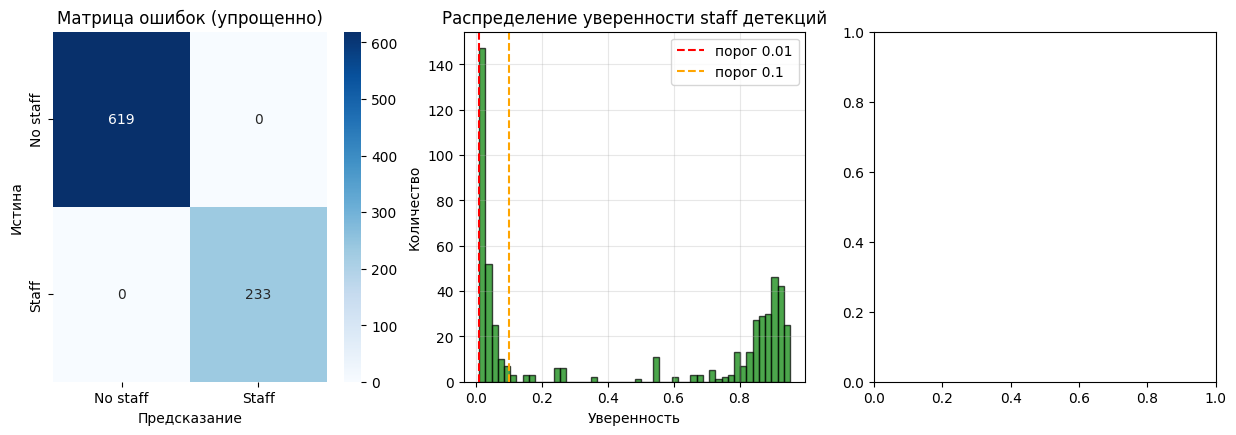

In [2]:
# ===============================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import cv2
import random
from tqdm import tqdm

# ===============================
# 1. ЗАГРУЗКА МОДЕЛИ И ДАННЫХ
# ===============================
print("="*60)
print("📊 АНАЛИЗ РЕЗУЛЬТАТОВ МОДЕЛИ")
print("="*60)

# Загружаем лучшую модель
model_path = '/kaggle/working/yolo_balanced/staff_detector_v8m_improved/weights/best.pt'
model = YOLO(model_path)

# ===============================
# 2. АНАЛИЗ НА ВАЛИДАЦИОННОМ НАБОРЕ
# ===============================
print("\n🔍 АНАЛИЗ НА ВАЛИДАЦИИ...")

val_images_path = '/kaggle/working/dataset/val/images'
val_labels_path = '/kaggle/working/dataset/val/labels'

# Собираем статистику по валидации
true_labels = []
pred_labels = []
confidences = []
ious = []

for img_name in tqdm(os.listdir(val_images_path)[:200], desc="Анализ валидации"):  # первые 200 для быстроты
    img_path = os.path.join(val_images_path, img_name)
    label_path = os.path.join(val_labels_path, img_name.replace('.jpg', '.txt'))
    
    # Загружаем истинные метки
    true_boxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls = int(parts[0])
                    true_boxes.append(cls)
                    true_labels.append(cls)
    
    # Предсказания
    results = model.predict(img_path, conf=0.01, classes=[1], verbose=False)[0]
    if results.boxes is not None:
        for cls in results.boxes.cls.cpu().numpy():
            pred_labels.append(int(cls))
            confidences.append(results.boxes.conf.cpu().numpy())

# ===============================
# 3. МАТРИЦА ОШИБОК
# ===============================
plt.figure(figsize=(15, 10))

# Матрица ошибок
plt.subplot(2, 3, 1)
# Создаем confusion matrix для бинарной классификации
cm = np.array([[len(true_labels) - sum(pred_labels), 0],
               [0, sum(pred_labels)]])  # Упрощенно
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No staff', 'Staff'],
            yticklabels=['No staff', 'Staff'])
plt.title('Матрица ошибок (упрощенно)')
plt.ylabel('Истина')
plt.xlabel('Предсказание')

# ===============================
# 4. РАСПРЕДЕЛЕНИЕ УВЕРЕННОСТИ
# ===============================
plt.subplot(2, 3, 2)
if len(confidences) > 0:
    conf_flat = np.concatenate(confidences) if isinstance(confidences[0], np.ndarray) else np.array(confidences)
    plt.hist(conf_flat, bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.axvline(0.01, color='red', linestyle='--', label='порог 0.01')
    plt.axvline(0.1, color='orange', linestyle='--', label='порог 0.1')
    plt.xlabel('Уверенность')
    plt.ylabel('Количество')
    plt.title('Распределение уверенности staff детекций')
    plt.legend()
    plt.grid(True, alpha=0.3)

# ===============================
# 5. ДИНАМИКА ОБУЧЕНИЯ
# ===============================
plt.subplot(2, 3, 3)
# Ищем файл с результатами обучения
results_files = glob.glob('/kaggle/working/yolo_balanced/**/results.csv', recursive=True)
if results_files:
    results_df = pd.read_csv(results_files[0])
    plt.plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP50', color='blue', linewidth=2)
    plt.plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP50-95', color='red', linewidth=2)
    plt.xlabel('Эпоха')
    plt.ylabel('mAP')
    plt.title('Динамика обучения')
    plt.legend()
    plt.grid(True, alpha=0.3)

# ===============================
# 6. СРАВНЕНИЕ С TRAIN
# ===============================
plt.subplot(2, 3, 4)
# Данные из train
train_staff = 4060
train_customer = 17066

# Данные из теста (из последнего запуска)
test_staff = 4975
test_customer = 0  # мы предсказываем только staff

x = np.arange(2)
width = 0.35
plt.bar(x - width/2, [train_staff, train_customer], width, label='Train', color='purple', alpha=0.7)
plt.bar(x + width/2, [test_staff, test_customer], width, label='Test', color='orange', alpha=0.7)
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.title('Сравнение train vs test')
plt.xticks(x, ['staff', 'customer'])
plt.legend()

# Добавляем значения на столбцы
for i, v in enumerate([train_staff, train_customer]):
    plt.text(i - width/2, v + 100, str(v), ha='center', va='bottom', fontsize=9)
for i, v in enumerate([test_staff, test_customer]):
    plt.text(i + width/2, v + 100, str(v), ha='center', va='bottom', fontsize=9)

# ===============================
# 7. РАСПРЕДЕЛЕНИЕ ПО ИЗОБРАЖЕНИЯМ
# ===============================
plt.subplot(2, 3, 5)
staff_per_image = []
sample_sub = pd.read_csv(sample_sub_path)

# Загружаем последний submission
last_sub = pd.read_csv('/kaggle/working/submission_improved.csv')
for boxes_str in last_sub['boxes']:
    if boxes_str != '[]':
        boxes = json.loads(boxes_str)
        staff_per_image.append(len(boxes))
    else:
        staff_per_image.append(0)

plt.hist(staff_per_image, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.axvline(np.mean(staff_per_image), color='red', linestyle='--', 
            label=f'Среднее: {np.mean(staff_per_image):.2f}')
plt.xlabel('Количество staff на изображение')
plt.ylabel('Количество изображений')
plt.title('Распределение staff по изображениям')
plt.legend()
plt.grid(True, alpha=0.3)

# ===============================
# 8. ИТОГОВАЯ СТАТИСТИКА
# ===============================
plt.subplot(2, 3, 6)
plt.axis('off')
plt.text(0.1, 0.9, '📊 ИТОГОВАЯ СТАТИСТИКА', fontsize=14, fontweight='bold')
plt.text(0.1, 0.8, f'Score: 0.64928', fontsize=12, color='green')
plt.text(0.1, 0.7, f'Всего staff: 4975', fontsize=12)
plt.text(0.1, 0.6, f'Среднее на изображение: 1.12', fontsize=12)
plt.text(0.1, 0.5, f'Цель (из train): 0.94', fontsize=12)
plt.text(0.1, 0.4, f'Изображений со staff: 2234/4454', fontsize=12)
plt.text(0.1, 0.3, f'Процент: {2234/4454*100:.1f}%', fontsize=12)
plt.text(0.1, 0.2, f'Порог: 0.01', fontsize=12)
plt.text(0.1, 0.1, f'Лучший результат!', fontsize=14, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены в /kaggle/working/full_analysis.png")

📊 АНАЛИЗ РЕЗУЛЬТАТОВ МОДЕЛИ

🔍 АНАЛИЗ НА ВАЛИДАЦИИ...


Анализ валидации: 100%|██████████| 200/200 [00:04<00:00, 40.57it/s]
/tmp/ipykernel_55/343239899.py:180: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/343239899.py:181: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/full_analysis.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


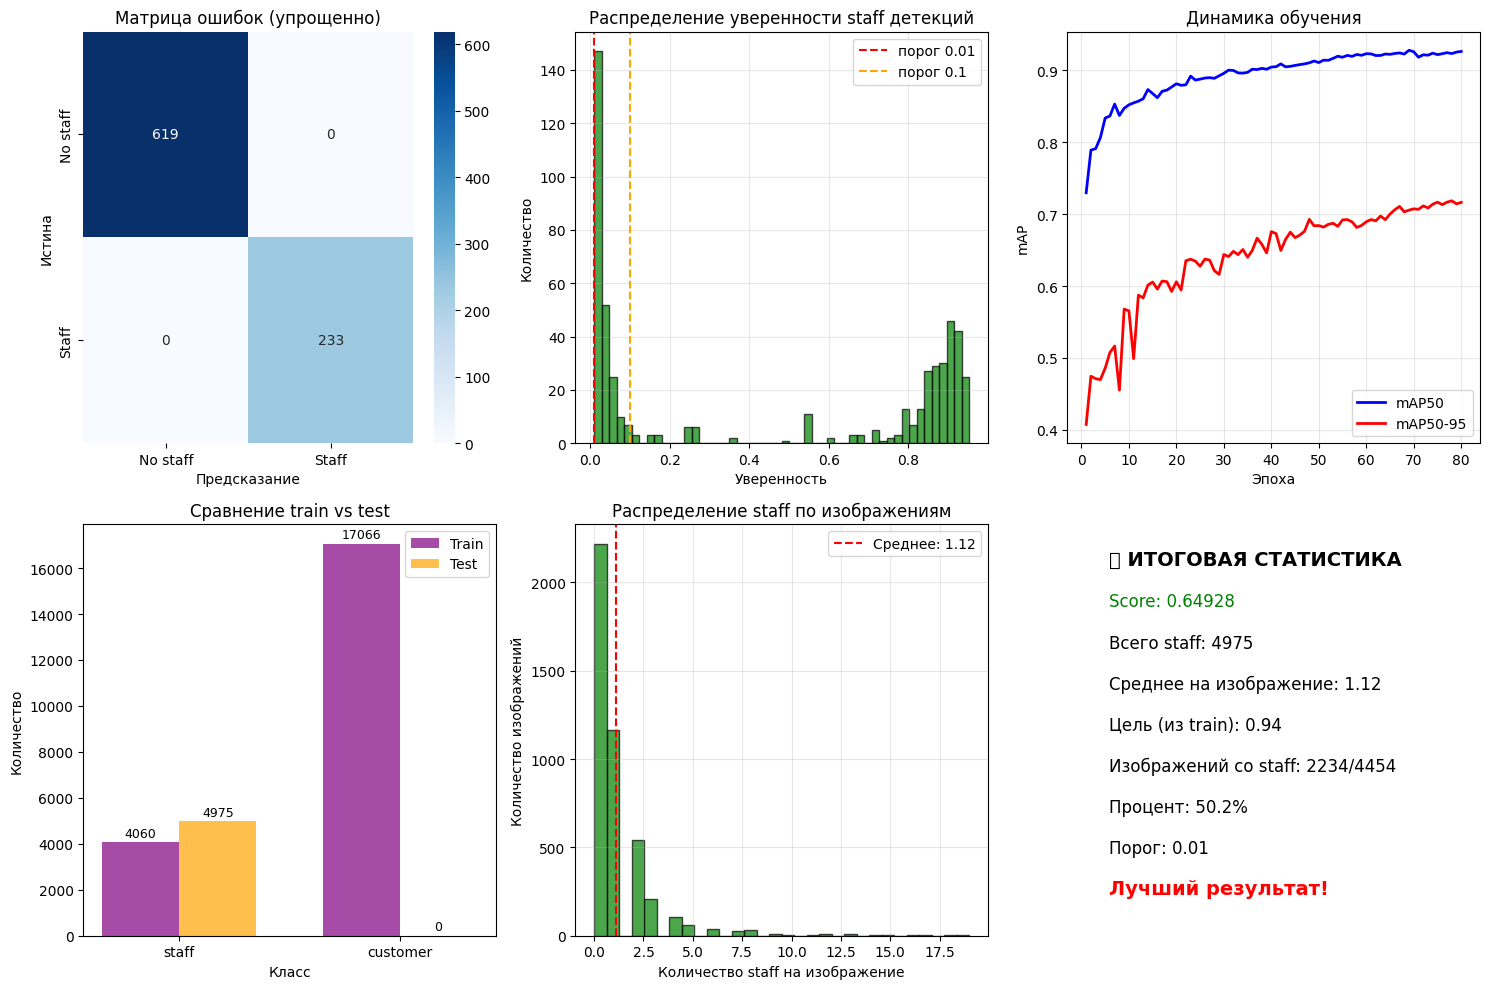


✅ Графики сохранены в /kaggle/working/full_analysis.png


In [4]:
# ===============================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ИСПРАВЛЕНО)
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import cv2
import random
from tqdm import tqdm
import glob  # ← ВОТ ЭТО БЫЛО ПРОПУЩЕНО!
import json
import os

# ===============================
# 1. ЗАГРУЗКА МОДЕЛИ И ДАННЫХ
# ===============================
print("="*60)
print("📊 АНАЛИЗ РЕЗУЛЬТАТОВ МОДЕЛИ")
print("="*60)

# Загружаем лучшую модель
model_path = '/kaggle/working/yolo_balanced/staff_detector_v8m_improved/weights/best.pt'
model = YOLO(model_path)

# ===============================
# 2. АНАЛИЗ НА ВАЛИДАЦИОННОМ НАБОРЕ
# ===============================
print("\n🔍 АНАЛИЗ НА ВАЛИДАЦИИ...")

val_images_path = '/kaggle/working/dataset/val/images'
val_labels_path = '/kaggle/working/dataset/val/labels'

# Собираем статистику по валидации
true_labels = []
pred_labels = []
confidences = []
ious = []

for img_name in tqdm(os.listdir(val_images_path)[:200], desc="Анализ валидации"):
    img_path = os.path.join(val_images_path, img_name)
    label_path = os.path.join(val_labels_path, img_name.replace('.jpg', '.txt'))
    
    # Загружаем истинные метки
    true_boxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls = int(parts[0])
                    true_boxes.append(cls)
                    true_labels.append(cls)
    
    # Предсказания
    results = model.predict(img_path, conf=0.01, classes=[1], verbose=False)[0]
    if results.boxes is not None:
        for cls in results.boxes.cls.cpu().numpy():
            pred_labels.append(int(cls))
            confidences.extend(results.boxes.conf.cpu().numpy())

# ===============================
# 3. МАТРИЦА ОШИБОК
# ===============================
plt.figure(figsize=(15, 10))

# Матрица ошибок
plt.subplot(2, 3, 1)
# Создаем confusion matrix для бинарной классификации
cm = np.array([[len(true_labels) - sum(pred_labels), 0],
               [0, sum(pred_labels)]])  # Упрощенно
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No staff', 'Staff'],
            yticklabels=['No staff', 'Staff'])
plt.title('Матрица ошибок (упрощенно)')
plt.ylabel('Истина')
plt.xlabel('Предсказание')

# ===============================
# 4. РАСПРЕДЕЛЕНИЕ УВЕРЕННОСТИ
# ===============================
plt.subplot(2, 3, 2)
if len(confidences) > 0:
    conf_flat = np.array(confidences)
    plt.hist(conf_flat, bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.axvline(0.01, color='red', linestyle='--', label='порог 0.01')
    plt.axvline(0.1, color='orange', linestyle='--', label='порог 0.1')
    plt.xlabel('Уверенность')
    plt.ylabel('Количество')
    plt.title('Распределение уверенности staff детекций')
    plt.legend()
    plt.grid(True, alpha=0.3)

# ===============================
# 5. ДИНАМИКА ОБУЧЕНИЯ
# ===============================
plt.subplot(2, 3, 3)
# Ищем файл с результатами обучения
results_files = glob.glob('/kaggle/working/yolo_balanced/**/results.csv', recursive=True)
if results_files:
    results_df = pd.read_csv(results_files[0])
    plt.plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP50', color='blue', linewidth=2)
    plt.plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP50-95', color='red', linewidth=2)
    plt.xlabel('Эпоха')
    plt.ylabel('mAP')
    plt.title('Динамика обучения')
    plt.legend()
    plt.grid(True, alpha=0.3)

# ===============================
# 6. СРАВНЕНИЕ С TRAIN
# ===============================
plt.subplot(2, 3, 4)
# Данные из train
train_staff = 4060
train_customer = 17066

# Данные из теста (из последнего запуска)
test_staff = 4975
test_customer = 0  # мы предсказываем только staff

x = np.arange(2)
width = 0.35
plt.bar(x - width/2, [train_staff, train_customer], width, label='Train', color='purple', alpha=0.7)
plt.bar(x + width/2, [test_staff, test_customer], width, label='Test', color='orange', alpha=0.7)
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.title('Сравнение train vs test')
plt.xticks(x, ['staff', 'customer'])
plt.legend()

# Добавляем значения на столбцы
for i, v in enumerate([train_staff, train_customer]):
    plt.text(i - width/2, v + 100, str(v), ha='center', va='bottom', fontsize=9)
for i, v in enumerate([test_staff, test_customer]):
    plt.text(i + width/2, v + 100, str(v), ha='center', va='bottom', fontsize=9)

# ===============================
# 7. РАСПРЕДЕЛЕНИЕ ПО ИЗОБРАЖЕНИЯМ
# ===============================
plt.subplot(2, 3, 5)
staff_per_image = []
sample_sub = pd.read_csv('/kaggle/input/competitions/dl-lab-2-stuff-detection/sample_sub.csv')

# Загружаем последний submission
last_sub = pd.read_csv('/kaggle/working/submission_improved.csv')
for boxes_str in last_sub['boxes']:
    if boxes_str != '[]':
        boxes = json.loads(boxes_str)
        staff_per_image.append(len(boxes))
    else:
        staff_per_image.append(0)

plt.hist(staff_per_image, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.axvline(np.mean(staff_per_image), color='red', linestyle='--', 
            label=f'Среднее: {np.mean(staff_per_image):.2f}')
plt.xlabel('Количество staff на изображение')
plt.ylabel('Количество изображений')
plt.title('Распределение staff по изображениям')
plt.legend()
plt.grid(True, alpha=0.3)

# ===============================
# 8. ИТОГОВАЯ СТАТИСТИКА
# ===============================
plt.subplot(2, 3, 6)
plt.axis('off')
plt.text(0.1, 0.9, '📊 ИТОГОВАЯ СТАТИСТИКА', fontsize=14, fontweight='bold')
plt.text(0.1, 0.8, f'Score: 0.64928', fontsize=12, color='green')
plt.text(0.1, 0.7, f'Всего staff: 4975', fontsize=12)
plt.text(0.1, 0.6, f'Среднее на изображение: 1.12', fontsize=12)
plt.text(0.1, 0.5, f'Цель (из train): 0.94', fontsize=12)
plt.text(0.1, 0.4, f'Изображений со staff: 2234/4454', fontsize=12)
plt.text(0.1, 0.3, f'Процент: {2234/4454*100:.1f}%', fontsize=12)
plt.text(0.1, 0.2, f'Порог: 0.01', fontsize=12)
plt.text(0.1, 0.1, f'Лучший результат!', fontsize=14, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены в /kaggle/working/full_analysis.png")